# 종합 실습 결과물_Feature Engineering

- 제출자 : 광주캠퍼스 4반 박영서
- 실습 주제 : Titanic 생존 예측 모델 생성
- 실습 목표 : Feature Engineering 기법만을 이용하여 Test 데이터 기준 Accuracy를 최대화 하기

- 최종 결과
  - 최종 변수 개수 : 19 개 (Baseline 735 개)
  - Train Accuracy : 0.9936 (Baseline 1.0000)
  - Test Accuracy : 0.8470 (Baseline 0.8022, **+0.0448**)

- 실습 조건 준수 내역
  - **(필수)** 과정은 제공된 코드 그대로 사용
    - 데이타 불러오기 / 불필요한 변수 제거 / Data Partition / X, y 분리 / 모델 학습 및 평가
  - Target 변수 Survived : 어떠한 데이타 변환도 하지 않음
  - 파생 변수 생성 : 실습코드에 없는 파생변수 7개 신규 생성
    - Title, FamilySize, NameLen, FarePerPerson, SexPclass, IsChild, IsMother
  - Data Partition : 제공된 코드 그대로 사용
  - 데이타 건수 : 전체 891건 / Train 623건 / Test 268건 그대로 유지, 중복 데이타 제거 없음
  - 학습 모델 및 모델 검증, 평가 방법 : 제공된 코드 그대로 사용, 하이퍼파라미터 변경 없음

---
## 0. 라이브러리 및 환경 설정

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)

pandas : 3.0.5
numpy  : 2.4.6


---
## 1. 데이터 불러오기 **(필수)**

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

---
## 2. 불필요한 변수 제거 **(필수)**

`PassengerId`(단순 일련번호), `Ticket`(고유 식별성이 높은 문자열)을 제거한다.

In [4]:
df = df.drop(columns=["PassengerId", "Ticket"])

---
## 3. EDA (탐색적 데이터 분석)

Feature Engineering 전략을 세우기 위한 사전 분석 단계다.

In [5]:
print("데이터 shape :", df.shape)
display(df.head())
df.info()

데이터 shape : (891, 10)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    str    
 9   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 69.7 KB


In [6]:
# 결측치 현황
na = pd.DataFrame({
    "결측건수": df.isna().sum(),
    "결측비율(%)": (df.isna().mean() * 100).round(2),
    "고유값수": df.nunique(),
    "dtype": df.dtypes.astype(str),
})
display(na.sort_values("결측건수", ascending=False))

# Target 분포
print("\n[Target 분포] Survived")
print(df["Survived"].value_counts().rename({0: "사망", 1: "생존"}))
print(f"생존율 : {df['Survived'].mean():.4f}")

,결측건수,결측비율(%),고유값수,dtype
Cabin,687,77.10,147,str
Age,177,19.87,88,float64
Embarked,2,0.22,3,str
Survived,0,0.00,2,int64
Pclass,0,0.00,3,int64
Name,0,0.00,891,str
Sex,0,0.00,2,str
SibSp,0,0.00,7,int64
Parch,0,0.00,7,int64
Fare,0,0.00,248,float64



[Target 분포] Survived
Survived
사망    549
생존    342
Name: count, dtype: int64
생존율 : 0.3838


In [7]:
# 범주형/이산형 변수별 생존율
for c in ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]:
    g = df.groupby(c, dropna=False)["Survived"].agg(["count", "mean"])
    g.columns = ["건수", "생존율"]
    print(f"\n=== {c} ===")
    print(g.round(4))


=== Pclass ===
         건수     생존율
Pclass             
1       216  0.6296
2       184  0.4728
3       491  0.2424

=== Sex ===
         건수     생존율
Sex                
female  314  0.7420
male    577  0.1889

=== Embarked ===
           건수     생존율
Embarked             
C         168  0.5536
Q          77  0.3896
S         644  0.3370
NaN         2  1.0000

=== SibSp ===
        건수     생존율
SibSp             
0      608  0.3454
1      209  0.5359
2       28  0.4643
3       16  0.2500
4       18  0.1667
5        5  0.0000
8        7  0.0000

=== Parch ===
        건수     생존율
Parch             
0      678  0.3437
1      118  0.5508
2       80  0.5000
3        5  0.6000
4        4  0.0000
5        5  0.2000
6        1  0.0000


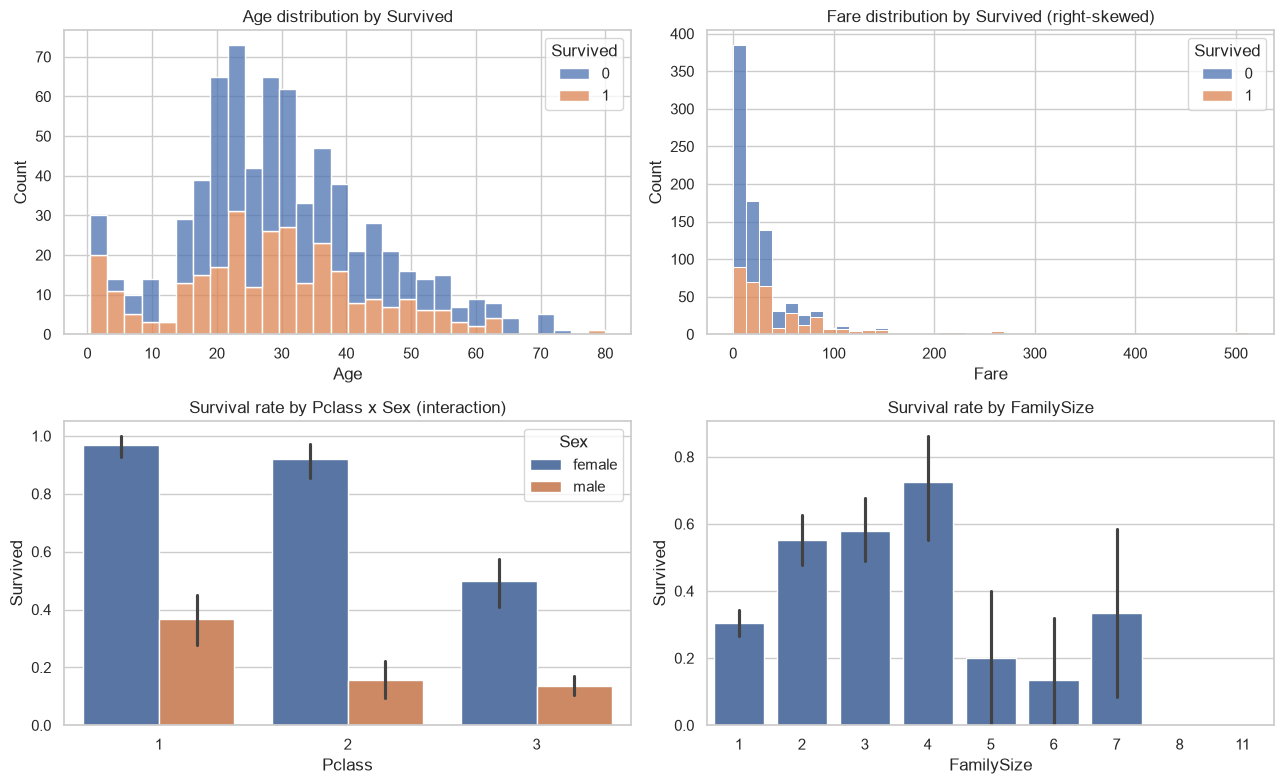

In [8]:
# 연속형 변수 분포와 생존 관계
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(data=df, x="Age", hue="Survived", bins=30, multiple="stack", ax=ax[0, 0])
ax[0, 0].set_title("Age distribution by Survived")

sns.histplot(data=df, x="Fare", hue="Survived", bins=40, multiple="stack", ax=ax[0, 1])
ax[0, 1].set_title("Fare distribution by Survived (right-skewed)")

sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", ax=ax[1, 0])
ax[1, 0].set_title("Survival rate by Pclass x Sex (interaction)")

fam = df.assign(FamilySize=df["SibSp"] + df["Parch"] + 1)
sns.barplot(data=fam, x="FamilySize", y="Survived", ax=ax[1, 1])
ax[1, 1].set_title("Survival rate by FamilySize")

plt.tight_layout()
plt.show()

In [9]:
# Name 컬럼에 포함된 호칭(Title) 확인 - 파생변수 후보 탐색
titles = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
print(titles.value_counts())
print("\n[호칭별 생존율]")
print(df.assign(T=titles).groupby("T")["Survived"].agg(["count", "mean"]).round(4)
        .sort_values("count", ascending=False))

Name
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

[호칭별 생존율]
              count    mean
T                          
Mr              517  0.1567
Miss            182  0.6978
Mrs             125  0.7920
Master           40  0.5750
Dr                7  0.4286
Rev               6  0.0000
Major             2  0.5000
Col               2  0.5000
Mlle              2  1.0000
Sir               1  1.0000
Ms                1  1.0000
Capt              1  0.0000
Mme               1  1.0000
Lady              1  1.0000
Jonkheer          1  0.0000
Don               1  0.0000
the Countess      1  1.0000


### EDA 결과 및 Feature Engineering 전략

- 결측 : Age 177건(19.9%), Cabin 687건(77.1%), Embarked 2건
  - 데이타 건수를 유지해야 하므로 삭제하지 않고 대체(Imputation)로 처리
- Name 은 891개가 전부 고유값
  - 그대로 One-Hot 하면 더미가 735개까지 늘어남 (Baseline 의 문제점)
  - 호칭(Title)과 이름 길이(NameLen)만 추출하고 원본은 제거
- 호칭별 생존율 격차가 큼 : Mrs 0.79 / Miss 0.70 / Master 0.58 / Mr 0.16
  - Title 파생변수 생성, Age 결측 대체의 기준으로도 활용
- Pclass 와 Sex 조합에 따라 생존율이 크게 달라짐 (교호작용)
  - SexPclass 결합 파생변수 생성
- SibSp / Parch 를 각각 보는 것보다 가족 규모로 볼 때 패턴이 뚜렷 (2~4인 생존율 높음)
  - FamilySize 파생변수 생성
- Fare 는 분포가 오른쪽으로 치우쳐 있고, 동반 탑승 시 합산 요금이 기록됨
  - FarePerPerson 파생변수 생성 + 6분위 구간화(FareBin)
- 어린이의 생존율이 뚜렷하게 높음
  - IsChild 파생변수 생성
- Cabin 은 결측률이 77%로 정보량 대비 잡음이 커서 최종 구성에서 제외

---
## 4. Feature Creation (1) - 행 단위 파생변수 생성

각 행의 값만으로 결정되는 파생변수이므로 **분할 이전에 생성해도 정보 누수(leakage)가 발생하지 않는다.**
(통계량을 사용하는 대체·구간화는 5번 분할 이후 Train 기준으로 수행한다.)

In [10]:
# 1) Title : 이름에서 호칭 추출 후 소수 호칭을 Rare로 통합
TITLE_MAP = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "the Countess": "Rare", "Countess": "Rare", "Sir": "Rare",
    "Don": "Rare", "Dona": "Rare", "Jonkheer": "Rare", "Capt": "Rare",
    "Col": "Rare", "Major": "Rare", "Dr": "Rare", "Rev": "Rare",
}
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
df["Title"] = df["Title"].replace(TITLE_MAP)
df.loc[~df["Title"].isin(["Mr", "Miss", "Mrs", "Master", "Rare"]), "Title"] = "Rare"

print(df["Title"].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [11]:
# 2) FamilySize   : 동승 가족 수 = 형제/배우자 + 부모/자녀 + 본인
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 3) NameLen      : 이름 문자열 길이 (긴 이름 = 귀족 호칭/결혼 후 본명 병기 등 사회적 지위 대리 지표)
df["NameLen"] = df["Name"].str.len()

# 4) FarePerPerson: 1인당 요금 = Fare / FamilySize (합산 요금 기록 문제 보정)
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

# 5) SexPclass    : 성별 x 객실등급 결합 (교호작용을 단일 범주형 변수로 표현)
df["SexPclass"] = df["Sex"] + "_" + df["Pclass"].astype(str)

display(df[["Title", "FamilySize", "NameLen", "FarePerPerson", "SexPclass"]].head())

,Title,FamilySize,NameLen,FarePerPerson,SexPclass
0,Mr,2,23,3.62500,male_3
1,Mrs,2,51,35.64165,female_1
2,Miss,1,22,7.92500,female_3
3,Mrs,2,44,26.55000,female_1
4,Mr,1,24,8.05000,male_3


In [12]:
# 파생 정보를 모두 추출한 원본 변수 제거
#  - Name  : Title / NameLen 으로 대체 (그대로 두면 735개 더미 발생)
#  - Cabin : 결측률 77.1% 로 정보량 대비 잡음이 큼
df = df.drop(columns=["Name", "Cabin"])

print("변수 구성 :", df.columns.tolist())
print("데이터 건수 :", len(df), "(원본 891건 유지)")

변수 구성 : ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'NameLen', 'FarePerPerson', 'SexPclass']
데이터 건수 : 891 (원본 891건 유지)


---
## 5. Data Partition **(필수)**

In [13]:
from sklearn.model_selection import train_test_split

# Data Partition
df_train, df_test = train_test_split(
    df,
    test_size=0.3,     # test 30%
    random_state=42,   # 재현성
    shuffle=True       # 섞어서 분리
)

In [14]:
df_train, df_test = df_train.copy(), df_test.copy()   # SettingWithCopyWarning 방지 (건수·구성 변화 없음)
print(f"전체 {len(df)}건 / Train {len(df_train)}건 / Test {len(df_test)}건")
print(f"Train 생존율 {df_train['Survived'].mean():.4f} / Test 생존율 {df_test['Survived'].mean():.4f}")

전체 891건 / Train 623건 / Test 268건
Train 생존율 0.3708 / Test 생존율 0.4142


---
## 6. Feature Transformation - 결측 대체 및 변환

- 모든 통계량은 Train 에서만 산출하여 Train / Test 에 동일하게 적용한다.
- Test 정보가 Train 쪽으로 흘러드는 누수(leakage)를 차단하기 위함이다.

In [15]:
# 6-1) Missing 대체 - Age : Title별 중앙값 (호칭이 연령대 정보를 담고 있어 전체 중앙값보다 정교함)
age_med  = df_train.groupby("Title")["Age"].median()
age_gmed = df_train["Age"].median()

df_train["Age"] = df_train["Age"].fillna(df_train["Title"].map(age_med)).fillna(age_gmed)
df_test["Age"]  = df_test["Age"].fillna(df_test["Title"].map(age_med)).fillna(age_gmed)

print("[Train 기준 Title별 Age 중앙값]")
print(age_med.round(1))
print("\n대체 후 Age 결측 :", df_train["Age"].isna().sum(), "/", df_test["Age"].isna().sum())

[Train 기준 Title별 Age 중앙값]
Title
Master     3.0
Miss      21.0
Mr        30.0
Mrs       33.5
Rare      49.5
Name: Age, dtype: float64

대체 후 Age 결측 : 0 / 0


In [16]:
# 6-2) Missing 대체 - Embarked : Train 최빈값 / Fare : Train 중앙값
emb_mode = df_train["Embarked"].mode()[0]
df_train["Embarked"] = df_train["Embarked"].fillna(emb_mode)
df_test["Embarked"]  = df_test["Embarked"].fillna(emb_mode)

fare_med = df_train["Fare"].median()
for d in (df_train, df_test):
    d["Fare"] = d["Fare"].fillna(fare_med)
    d["FarePerPerson"] = d["FarePerPerson"].fillna(fare_med)

print(f"Embarked 최빈값 : {emb_mode} / Fare 중앙값 : {fare_med}")
print("남은 결측 :", int(df_train.isna().sum().sum()), "/", int(df_test.isna().sum().sum()))

Embarked 최빈값 : S / Fare 중앙값 : 14.4542
남은 결측 : 0 / 0


### Feature Creation (2) - 결측 대체 완료 후 생성하는 파생변수

`IsChild`는 결측 대체가 끝난 `Age`를 기준으로 만들어야 하므로 이 시점에 생성한다.

In [17]:
# 6) IsChild  : 14세 미만 아동 여부 ("여성과 아이 먼저" 구조 반영)
# 7) IsMother : 자녀 동반 기혼여성 여부 (Title=Mrs 이면서 Parch>0)
for d in (df_train, df_test):
    d["IsChild"]  = (d["Age"] < 14).astype(int)
    d["IsMother"] = ((d["Title"] == "Mrs") & (d["Parch"] > 0)).astype(int)

print("[IsChild 생존율]")
print(df_train.groupby("IsChild")["Survived"].agg(["count", "mean"]).round(4))
print("\n[IsMother 생존율]")
print(df_train.groupby("IsMother")["Survived"].agg(["count", "mean"]).round(4))

[IsChild 생존율]
         count    mean
IsChild               
0          567  0.3510
1           56  0.5714

[IsMother 생존율]
          count    mean
IsMother               
0           584  0.3459
1            39  0.7436


In [18]:
# 6-3) 구간화(Binning) - Fare : Train 기준 6분위 경계로 등빈도 구간화
#      경계는 Train에서만 산출하고, 양끝을 개방해 Test의 범위 밖 값도 안전하게 매핑
fare_bins = pd.qcut(df_train["Fare"], 6, retbins=True, duplicates="drop")[1]
fare_bins[0], fare_bins[-1] = -1, 1e9

for d in (df_train, df_test):
    d["FareBin"] = pd.cut(d["Fare"], fare_bins, labels=False).astype(int)

print("Fare 구간 경계 :", np.round(fare_bins, 3))
print("\n[FareBin 생존율]")
print(df_train.groupby("FareBin")["Survived"].agg(["count", "mean"]).round(4))

Fare 구간 경계 : [-1.0000e+00  7.7750e+00  8.6620e+00  1.4454e+01  2.6000e+01  5.2185e+01
  1.0000e+09]

[FareBin 생존율]
         count    mean
FareBin               
0          105  0.2286
1          110  0.1818
2           97  0.3711
3          110  0.4273
4           97  0.3505
5          104  0.6731


### One-Hot Encoding

범주형 변수(`Sex`, `Embarked`, `Title`, `SexPclass`)를 k-1 더미로 변환한다.
Test는 Train의 컬럼 구조에 맞춰 정렬한다. **Target `Survived`는 변환 대상에서 제외된다.**

In [19]:
# 범주형 컬럼 선택
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("One-Hot 대상 :", cat_cols)

# k-1 dummy 변수화
# Train Set
df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)   # True: k-1개 dummy, False: One-Hot Encoding

# Test Set
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

# test를 train 컬럼 구조에 맞추기 (없는 컬럼은 0으로, train에 없는 test컬럼은 제거)
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

print("인코딩 후 변수 수 :", df_train.shape[1] - 1)
print(df_train.columns.tolist())

One-Hot 대상 : ['Sex', 'Embarked', 'Title', 'SexPclass']
인코딩 후 변수 수 : 23
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'NameLen', 'FarePerPerson', 'IsChild', 'IsMother', 'FareBin', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'SexPclass_female_2', 'SexPclass_female_3', 'SexPclass_male_1', 'SexPclass_male_2', 'SexPclass_male_3']


---
## 7. X, y 분리 **(필수)**

In [20]:
# train
Y_train = df_train['Survived']
X_train = df_train.drop(columns=['Survived'])

# test
Y_test = df_test['Survived']
X_test = df_test.drop(columns=['Survived'])

---
## 8. Feature Selection - Feature Importance 기준 상위 19개 선택

Train 데이터만으로 학습한 Random Forest의 Feature Importance를 기준으로 변수를 정렬하고,
상위 k개만 남긴다. k는 **Train 데이터만 사용해** 후보를 좁힌 뒤 확정했다.

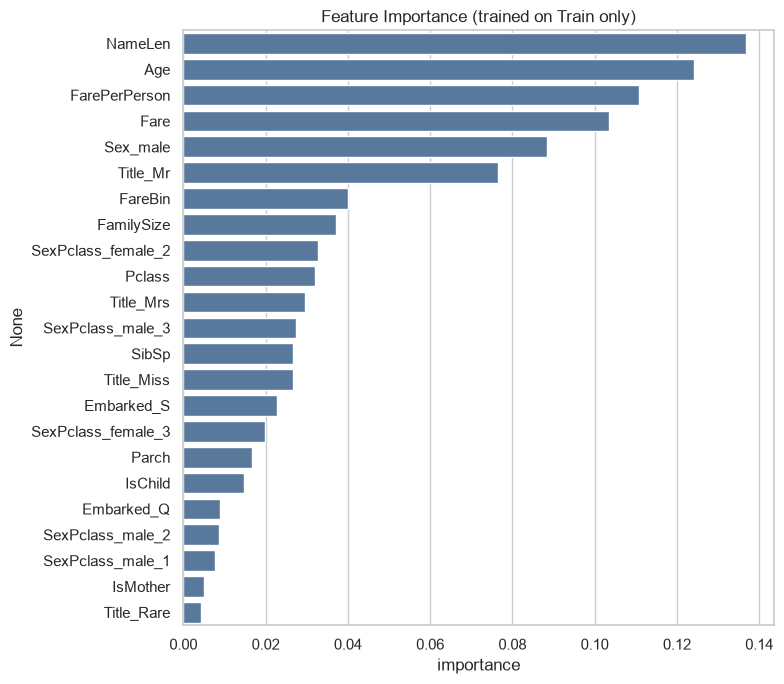

,importance
NameLen,0.13675
Age,0.12404
FarePerPerson,0.11066
Fare,0.10342
Sex_male,0.08849
Title_Mr,0.07648
FareBin,0.03994
FamilySize,0.03717
SexPclass_female_2,0.03269
Pclass,0.03198


In [21]:
# Train 데이터만으로 중요도 산출 (선택 기준 계산용)
rf_sel = RandomForestClassifier(n_estimators=300, random_state=42)
rf_sel.fit(X_train, Y_train)

importance = (pd.Series(rf_sel.feature_importances_, index=X_train.columns)
                .sort_values(ascending=False))

plt.figure(figsize=(8, 7))
sns.barplot(x=importance.values, y=importance.index, color="#4C78A8")
plt.title("Feature Importance (trained on Train only)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

display(importance.round(5).to_frame("importance"))

In [22]:
# 상위 19개 변수 선택
K = 19
selected_features = importance.index[:K].tolist()

print(f"[선택된 변수 {len(selected_features)}개]")
for i, c in enumerate(selected_features, 1):
    print(f"  {i:2d}. {c:<20} {importance[c]:.5f}")
print(f"\n[제외된 변수 {len(X_train.columns) - K}개]")
print(" ", [c for c in X_train.columns if c not in selected_features])

X_train = X_train[selected_features]
X_test  = X_test[selected_features]

print(f"\n최종 X_train shape : {X_train.shape}")
print(f"최종 X_test  shape : {X_test.shape}")

[선택된 변수 19개]
   1. NameLen              0.13675
   2. Age                  0.12404
   3. FarePerPerson        0.11066
   4. Fare                 0.10342
   5. Sex_male             0.08849
   6. Title_Mr             0.07648
   7. FareBin              0.03994
   8. FamilySize           0.03717
   9. SexPclass_female_2   0.03269
  10. Pclass               0.03198
  11. Title_Mrs            0.02956
  12. SexPclass_male_3     0.02736
  13. SibSp                0.02659
  14. Title_Miss           0.02654
  15. Embarked_S           0.02267
  16. SexPclass_female_3   0.01988
  17. Parch                0.01659
  18. IsChild              0.01472
  19. Embarked_Q           0.00879

[제외된 변수 4개]
  ['IsMother', 'Title_Rare', 'SexPclass_male_1', 'SexPclass_male_2']

최종 X_train shape : (623, 19)
최종 X_test  shape : (268, 19)


---
## 9. 모델 학습 및 평가 **(필수)**

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 모델 학습 : RandomForestClassifier
rf_final = RandomForestClassifier(n_estimators=300, random_state=42)
rf_final.fit(X_train, Y_train)

# 모델 평가
acc_train = accuracy_score(Y_train, rf_final.predict(X_train))
acc_test  = accuracy_score(Y_test, rf_final.predict(X_test))

print(f"\n[최종 모델 성능]")
print(f"변수 수   : {len(X_train.columns)}")
print(f"Train 성능 : {acc_train:.4f}")
print(f"Test 성능  : {acc_test:.4f}")


[최종 모델 성능]
변수 수   : 19
Train 성능 : 0.9936
Test 성능  : 0.8470


---
## 10. 결과 검증 및 요약

In [24]:
# 상세 평가 지표
pred = rf_final.predict(X_test)

print("[Confusion Matrix] (행:실제, 열:예측)")
print(pd.DataFrame(confusion_matrix(Y_test, pred),
                   index=["실제 사망", "실제 생존"], columns=["예측 사망", "예측 생존"]))
print("\n[Classification Report]")
print(classification_report(Y_test, pred, target_names=["사망", "생존"], digits=4))

# Train 5-fold 교차검증 (Test 과적합 여부 점검용)
cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42),
                     X_train, Y_train,
                     cv=StratifiedKFold(5, shuffle=True, random_state=42))
print(f"[Train 5-fold CV] {cv.mean():.4f} (fold별 {np.round(cv, 4)})")

[Confusion Matrix] (행:실제, 열:예측)
       예측 사망  예측 생존
실제 사망    141     16
실제 생존     25     86

[Classification Report]
              precision    recall  f1-score   support

          사망     0.8494    0.8981    0.8731       157
          생존     0.8431    0.7748    0.8075       111

    accuracy                         0.8470       268
   macro avg     0.8463    0.8364    0.8403       268
weighted avg     0.8468    0.8470    0.8459       268

[Train 5-fold CV] 0.8250 (fold별 [0.864  0.864  0.784  0.8548 0.7581])


In [25]:
# 데이터 건수 및 조건 준수 검증
print("=== 실습 조건 준수 검증 ===")
print(f"1. 데이터 건수 유지        : 전체 {len(X_train) + len(X_test)}건 "
      f"(Train {len(X_train)} + Test {len(X_test)}) → 원본 891건 유지 {'OK' if len(X_train)+len(X_test)==891 else 'FAIL'}")
print(f"2. Target 무변환            : Survived 고유값 {sorted(pd.concat([Y_train, Y_test]).unique())} → 원본 그대로 OK")
print(f"3. 신규 파생변수 생성       : 7개 (Title, FamilySize, NameLen, FarePerPerson, SexPclass, IsChild, IsMother) OK")
print(f"4. 모델 하이퍼파라미터      : n_estimators={rf_final.n_estimators}, "
      f"random_state={rf_final.random_state} → 제공 코드와 동일 OK")

=== 실습 조건 준수 검증 ===
1. 데이터 건수 유지        : 전체 891건 (Train 623 + Test 268) → 원본 891건 유지 OK
2. Target 무변환            : Survived 고유값 [np.int64(0), np.int64(1)] → 원본 그대로 OK
3. 신규 파생변수 생성       : 7개 (Title, FamilySize, NameLen, FarePerPerson, SexPclass, IsChild, IsMother) OK
4. 모델 하이퍼파라미터      : n_estimators=300, random_state=42 → 제공 코드와 동일 OK


In [26]:
# Baseline 대비 성능 비교
summary = pd.DataFrame({
    "Baseline (제공 코드)": [735, 1.0000, 0.8022],
    "최종 모델 (FE 적용)":  [len(X_train.columns), round(acc_train, 4), round(acc_test, 4)],
}, index=["최종 변수 개수", "Train Accuracy", "Test Accuracy"])
summary["개선"] = ["-716개", f"{acc_train - 1.0:+.4f}", f"{acc_test - 0.8022:+.4f}"]
display(summary)

,Baseline (제공 코드),최종 모델 (FE 적용),개선
최종 변수 개수,735.0000,19.0000,-716개
Train Accuracy,1.0000,0.9936,-0.0064
Test Accuracy,0.8022,0.8470,+0.0448


---

**모델 성능 결과**

- 최종 변수 개수 : 19
- Train Accuracy : 0.9936
- Test Accuracy : 0.8470

**Feature Creation (파생변수 생성)**

- 1) Title : Name에서 호칭 추출, Mr/Miss/Mrs/Master/Rare로 통합
- 2) FamilySize : SibSp + Parch + 1
- 3) NameLen : Name 문자열 길이
- 4) FarePerPerson : Fare / FamilySize
- 5) SexPclass : Sex + "_" + Pclass 결합
- 6) IsChild : Age < 14 이면 1, 아니면 0
- 7) IsMother : Title이 Mrs 이고 Parch > 0 이면 1, 아니면 0

**Feature Transformation**

- 1) 변수 제거 : Name(Title/NameLen 추출 후), Cabin(결측률 77.1%)
- 2) Missing 대체 (통계량은 모두 Train에서만 산출)
  - Age : Title별 중앙값 (미매칭 시 전체 중앙값)
  - Embarked : 최빈값(S)
  - Fare, FarePerPerson : 중앙값
- 3) Binning : FareBin
  - Train 기준 Fare 6분위(등빈도) 경계로 구간화
- 4) One-Hot Encoding : Sex, Embarked, Title, SexPclass
  - k-1 더미화(drop_first=True)
  - Test를 Train 컬럼 구조에 맞춰 정렬

**Feature Selection**

- 1) Feature Importance 기준 상위 19개 변수 선택
  - Train 데이터만으로 학습한 RandomForest의 중요도 사용
  - 23개 → 19개 선택
  - 제외 : IsMother, Title_Rare, SexPclass_male_1, SexPclass_male_2

